In [1]:
# compile results
import pickle

homedir = "/mnt/mirabelle/az6922_homedir/"
cm_list = ["unv1","prv1"]
nfaillinks_list_dict = dict()
nfaillinks_list_dict["leafspine_before"] = [40,81,122,163,204]
nfaillinks_list_dict["dringsu2_before"] = [42,85,127,170,213]
nfaillinks_list_dict["dringsu2_after"] = [42,85,127,170,213]
fseed_list = range(10)
scheme_list = ["dringsu2_before","leafspine_before","dringsu2_after"]
failpct_list = [0,2,4,6,8,10]
load_dict = dict()
load_dict["unv1"] = 2 #4
load_dict["prv1"] = 2 #3
seed = 1

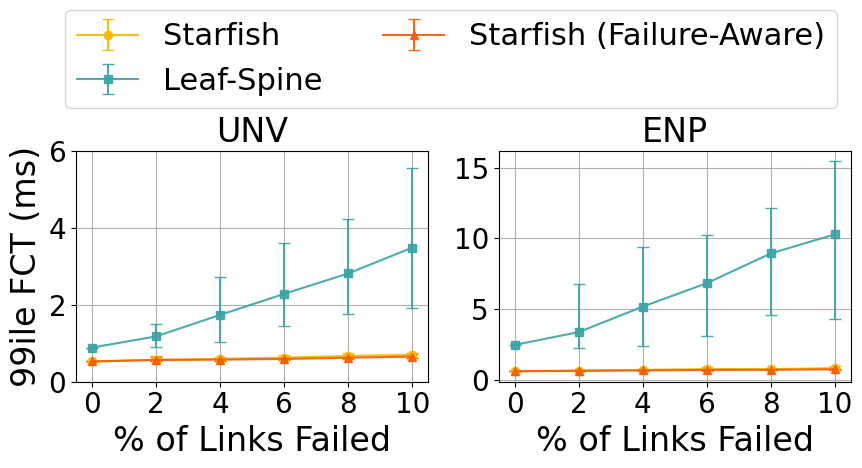

In [5]:
# plot from txt instead of pickle -- pickle files are too large
import matplotlib.pyplot as plt
import numpy as np

plottitledict = {"unv1":"UNV","prv1":"ENP","cluster_a":"DB","cluster_b":"WS","cluster_c":"HD"}
plotlabeldict = {"dringsu2_after":"Starfish (Failure-Aware)","dringsu2_before":"Starfish","leafspine_before":"Leaf-Spine"}
plotmarkers = ['o', 's', '^', 'v', 'D', 'P', '*', 'X', 'h', '1']
plotcolordict = {"dringsu2_after":"#f35b04","leafspine_before":"#38a3a5","dringsu2_before":"#f7b801"}


plotdatadict = dict()
sumfile = "fct_summary.txt"
with open(sumfile,'r') as f:
    # cluster_a/outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
    lines = f.readlines()
    for line in lines:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split('/')
        cm = outfiletokens[0]
        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotdatadict:
            plotdatadict[cm] = dict()
        plotdatadict[cm][outfile] = p99

plotevalmaindatadict = dict()
sumfile = "../eval_main/fct_summary.txt"
with open(sumfile,'r') as f:
    # cluster_a/outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
    lines = f.readlines()
    for line in lines:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split('/')
        cm = outfiletokens[0]
        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotevalmaindatadict:
            plotevalmaindatadict[cm] = dict()
        plotevalmaindatadict[cm][outfile] = p99


nr = 1
nc = len(cm_list)
fig, axs =plt.subplots(nr, nc, figsize=(nc*5, nr*3))
for ic,cm in enumerate(cm_list):
    for isc,scheme in enumerate(scheme_list):
        fct_list = list()
        load = load_dict[cm]
        fct_list_allseeds = list()
        if "dring" in scheme:
            myscheme = "dringsu2"
        else:
            myscheme = "leafspine"
        outfile = f"{cm}/outfiles/{myscheme}_load{load}_seed{seed}.out"
        p99 = plotevalmaindatadict[cm][outfile]
        fct_list_allseeds.append(p99)
        fct_list.append(fct_list_allseeds)

        for nfaillinks in nfaillinks_list_dict[scheme]:
            fct_list_allseeds = list()
            for fseed in fseed_list:
                outfile = f"{cm}/outfiles/{scheme}_nfaillinks{nfaillinks}_fseed{fseed}.out"
                p99 = plotdatadict[cm][outfile]
                fct_list_allseeds.append(p99)
            fct_list.append(fct_list_allseeds)
        
        if ic==0:
            axs[ic].errorbar(failpct_list, [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker=plotmarkers[isc], label=plotlabeldict[scheme],alpha=0.9, capsize=4, color=plotcolordict[scheme])
        else:
            axs[ic].errorbar(failpct_list, [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker=plotmarkers[isc],alpha=0.9, capsize=4, color=plotcolordict[scheme])

    axs[ic].set_xlabel("% of Links Failed", fontsize=24)
    axs[ic].set_title(plottitledict[cm], fontsize=24)
    axs[ic].tick_params(axis='both', labelsize=20)
    axs[ic].grid(True)
    axs[ic].set_xticks([0, 2, 4, 6, 8, 10])

axs[0].set_ylabel("99ile FCT (ms)", fontsize=24)
axs[0].set_yticks(range(0,7,2))
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.4), ncol=2, fontsize=22)
plt.savefig(f"eval_failure_link.pdf", dpi=600, bbox_inches='tight')

unv1,dringsu2_before: [0.525801, 0.7015067]
unv1,leafspine_before: [0.887153, 3.482246]
unv1,dringsu2_after: [0.525801, 0.6518976000000001]
prv1,dringsu2_before: [0.594044, 0.814517]
prv1,leafspine_before: [2.45787, 10.286278000000001]
prv1,dringsu2_after: [0.594044, 0.7317239]

In [29]:
# unv1, leafspine vs dringsu2_before:
print((3.482246-0.887153)/0.887153)
print((0.7015067-0.525801)/0.525801)

# prv1, leafspine vs dringsu2_before:
print((10.286278000000001-2.45787)/2.45787)
print((0.814517-0.594044)/0.594044)

# unv1, dringsu2_before vs dringsu2_after:
print((0.6518976000000001-0.7015067)/0.6518976000000001)

# prv1, dringsu2_before vs dringsu2_after:
print((0.7317239-0.814517)/0.7317239)

2.9251921596387547
0.33416767940722836
3.185037451126382
0.3711391748759352
-0.0760995285149078
-0.11314800568903116


In [28]:
import matplotlib.pyplot as plt
import numpy as np

plottitledict = {"unv1":"UNV","prv1":"ENP","cluster_a":"DB","cluster_b":"WS","cluster_c":"HD"}
plotlabeldict = {"dringsu2_after":"Starfish (Failure-Aware)","dringsu2_before":"Starfish","leafspine_before":"Leaf-Spine"}
plotmarkers = ['o', 's', '^', 'v', 'D', 'P', '*', 'X', 'h', '1']
plotcolordict = {"dringsu2_after":"#f35b04","leafspine_before":"#38a3a5","dringsu2_before":"#f7b801"}


plotdatadict = dict()
sumfile = "fct_summary.txt"
with open(sumfile,'r') as f:
    # cluster_a/outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
    lines = f.readlines()
    for line in lines:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split('/')
        cm = outfiletokens[0]
        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotdatadict:
            plotdatadict[cm] = dict()
        plotdatadict[cm][outfile] = p99

plotevalmaindatadict = dict()
sumfile = "../eval_main/fct_summary.txt"
with open(sumfile,'r') as f:
    # cluster_a/outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
    lines = f.readlines()
    for line in lines:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split('/')
        cm = outfiletokens[0]
        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotevalmaindatadict:
            plotevalmaindatadict[cm] = dict()
        plotevalmaindatadict[cm][outfile] = p99


nr = 1
nc = len(cm_list)
# fig, axs =plt.subplots(nr, nc, figsize=(nc*5, nr*4))
for ic,cm in enumerate(cm_list):
    for isc,scheme in enumerate(scheme_list):
        fct_list = list()
        load = load_dict[cm]
        fct_list_allseeds = list()
        if "dring" in scheme:
            myscheme = "dringsu2"
        else:
            myscheme = "leafspine"
        outfile = f"{cm}/outfiles/{myscheme}_load{load}_seed{seed}.out"
        p99 = plotevalmaindatadict[cm][outfile]
        fct_list_allseeds.append(p99)
        fct_list.append(fct_list_allseeds)

        for nfaillinks in nfaillinks_list_dict[scheme]:
            fct_list_allseeds = list()
            for fseed in fseed_list:
                outfile = f"{cm}/outfiles/{scheme}_nfaillinks{nfaillinks}_fseed{fseed}.out"
                p99 = plotdatadict[cm][outfile]
                fct_list_allseeds.append(p99)
            fct_list.append(fct_list_allseeds)

        print(f"{cm},{scheme}: {[sum(x)/len(x) for x in fct_list]}")

unv1,dringsu2_before: [0.525801, 0.57024, 0.5947775999999999, 0.6269427000000001, 0.6698432000000001, 0.7015067]
unv1,leafspine_before: [0.887153, 1.1763422000000001, 1.7347129999999997, 2.281259, 2.811106, 3.482246]
unv1,dringsu2_after: [0.525801, 0.564959, 0.5740625, 0.5909703, 0.6236408999999999, 0.6518976000000001]
prv1,dringsu2_before: [0.594044, 0.6370581, 0.693147, 0.7479150999999999, 0.7426890000000002, 0.814517]
prv1,leafspine_before: [2.45787, 3.363888, 5.169271999999999, 6.827838, 8.938208999999999, 10.286278000000001]
prv1,dringsu2_after: [0.594044, 0.624055, 0.6525896, 0.6852657000000001, 0.6960706, 0.7317239]
